In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load processed data
crypto_df = pd.read_csv("../Data/processed/crypto_prices_processed.csv")
crypto_df["Date"] = pd.to_datetime(crypto_df["Date"])

crypto_df.head()

,Date,coin,Open,High,Low,Close,Volume,daily_return,cumulative_return
0,2020-01-01,ADA,0.032832,0.033813,0.032704,0.033458,22948374,NaN,NaN
1,2020-01-02,ADA,0.033474,0.033507,0.032448,0.032751,20843934,-0.021131,-0.021131
2,2020-01-03,ADA,0.032748,0.034427,0.032491,0.034180,30162644,0.043632,0.021579
3,2020-01-04,ADA,0.034191,0.034685,0.033872,0.034595,29535781,0.012142,0.033983
4,2020-01-05,ADA,0.034574,0.035356,0.034545,0.034721,21479178,0.003642,0.037749


In [3]:
# returns pivot table
returns_pivot = crypto_df.pivot(index="Date", columns="coin", values="daily_return")
returns_pivot.head()

coin,ADA,BNB,BTC,DOGE,DOT,ETH,LTC,SOL,XRP
Date,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,-0.021131,-0.048365,-0.029819,-0.011805,NaN,-0.025931,-0.052233,NaN,-0.024000
2020-01-03,0.043632,0.048625,0.051452,0.067695,NaN,0.053069,0.065102,NaN,0.029132
2020-01-04,0.012142,0.016915,0.008955,0.044755,NaN,0.006690,0.021479,NaN,0.004310
2020-01-05,0.003642,0.015802,0.000089,0.079429,NaN,0.008939,0.005230,NaN,0.006082


In [4]:
# Remove missing values
returns_pivot = returns_pivot.dropna()
returns_pivot.shape

(2044, 9)

In [5]:
# Annual returns and covariance
annual_returns = returns_pivot.mean() * 252
cov_matrix = returns_pivot.cov() * 252

annual_returns

coin
ADA     0.415375
BNB     0.640499
BTC     0.338825
DOGE    1.170226
DOT     0.272070
ETH     0.418735
LTC     0.246778
SOL     0.887440
XRP     0.567589
dtype: float64

In [6]:
# Simulation parameters
num_portfolios = 10000
coins = annual_returns.index.tolist()
num_assets = len(coins)

In [7]:
# Monte Carlo simulation
results = []
weights_list = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights)
    
    portfolio_return = np.dot(weights, annual_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = portfolio_return / portfolio_volatility
    
    results.append([portfolio_return, portfolio_volatility, sharpe_ratio])
    weights_list.append(weights)

In [8]:
# Results DataFrame
results_df = pd.DataFrame(results, columns=["return", "volatility", "sharpe_ratio"])

weights_df = pd.DataFrame(weights_list, columns=coins)

portfolio_df = pd.concat([results_df, weights_df], axis=1)

portfolio_df.head()

,return,volatility,sharpe_ratio,ADA,BNB,BTC,DOGE,DOT,ETH,LTC,SOL,XRP
0,0.526694,0.674501,0.780865,0.187010,0.000317,0.037091,0.078633,0.124674,0.144805,0.106028,0.128368,0.193074
1,0.511293,0.615214,0.831081,0.028052,0.219910,0.114083,0.021167,0.063133,0.056994,0.150646,0.064878,0.281137
2,0.617039,0.703076,0.877628,0.128256,0.009903,0.051691,0.095304,0.125686,0.033829,0.059588,0.262422,0.233321
3,0.563100,0.646617,0.870840,0.215391,0.082818,0.060076,0.057627,0.008716,0.282387,0.022743,0.166265,0.103978
4,0.497628,0.641935,0.775200,0.181024,0.065469,0.131035,0.036752,0.157589,0.072011,0.051482,0.107719,0.196918


In [9]:
# Max sharpe ratio portfolio
max_sharpe_portfolio = portfolio_df.loc[portfolio_df["sharpe_ratio"].idxmax()]
max_sharpe_portfolio

return          0.735338
volatility      0.680604
sharpe_ratio    1.080419
ADA             0.016935
BNB             0.329628
BTC             0.125778
DOGE            0.182985
DOT             0.017516
ETH             0.007096
LTC             0.020703
SOL             0.242826
XRP             0.056533
Name: 3464, dtype: float64

In [10]:
# Min volatility portfolio
min_vol_portfolio = portfolio_df.loc[portfolio_df["volatility"].idxmin()]
min_vol_portfolio

return          0.414359
volatility      0.554968
sharpe_ratio    0.746635
ADA             0.076724
BNB             0.089158
BTC             0.413174
DOGE            0.019315
DOT             0.071272
ETH             0.019451
LTC             0.205258
SOL             0.077016
XRP             0.028632
Name: 3499, dtype: float64

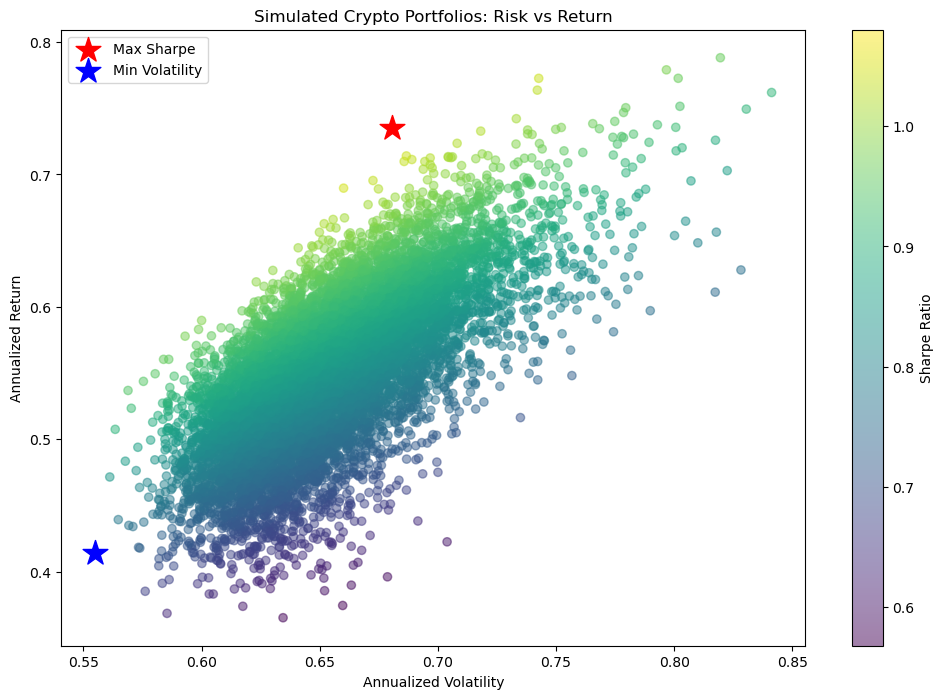

In [18]:
# Plot portfolio simulations
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    portfolio_df["volatility"],
    portfolio_df["return"],
    c=portfolio_df["sharpe_ratio"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    max_sharpe_portfolio["volatility"],
    max_sharpe_portfolio["return"],
    color="red",
    marker="*",
    s=350,
    label="Max Sharpe"
)

plt.scatter(
    min_vol_portfolio["volatility"],
    min_vol_portfolio["return"],
    color="blue",
    marker="*",
    s=350,
    label="Min Volatility"
)

plt.title("Simulated Crypto Portfolios: Risk vs Return")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()

In [12]:
# Max sharpe weights
max_sharpe_weights = max_sharpe_portfolio[coins].sort_values(ascending=False)
max_sharpe_weights

BNB     0.329628
SOL     0.242826
DOGE    0.182985
BTC     0.125778
XRP     0.056533
LTC     0.020703
DOT     0.017516
ADA     0.016935
ETH     0.007096
Name: 3464, dtype: float64

### The maximum Sharpe portfolio prioritised cryptocurrencies that delivered the best historical return relative to volatility. In this simulation, BNB and SOL dominated the optimal allocation, while BTC remained present as a stabilising major asset.

In [13]:
# Min volatility weights
min_vol_weights = min_vol_portfolio[coins].sort_values(ascending=False)
min_vol_weights

BTC     0.413174
LTC     0.205258
BNB     0.089158
SOL     0.077016
ADA     0.076724
DOT     0.071272
XRP     0.028632
ETH     0.019451
DOGE    0.019315
Name: 3499, dtype: float64

### The minimum volatility portfolio was much more concentrated in Bitcoin and Litecoin, suggesting that these assets offered the most stabilising effect within the selected universe. In contrast, highly volatile coins such as DOGE received minimal allocation in a low-risk strategy.

In [14]:
# Calculate percentage
(max_sharpe_weights * 100).round(2)
(min_vol_weights * 100).round(2)

BTC     41.32
LTC     20.53
BNB      8.92
SOL      7.70
ADA      7.67
DOT      7.13
XRP      2.86
ETH      1.95
DOGE     1.93
Name: 3499, dtype: float64

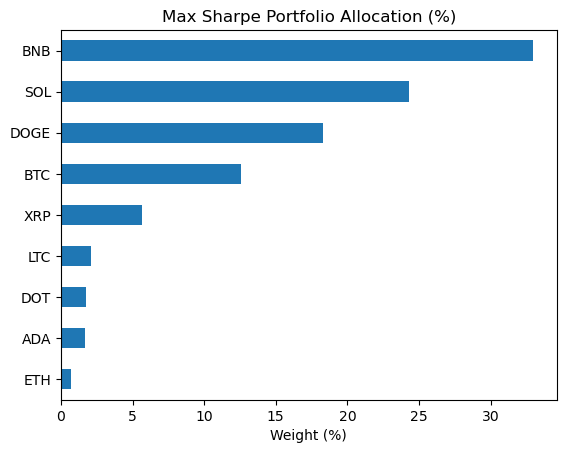

In [15]:
# Max sharpe allocation
(max_sharpe_weights * 100).sort_values().plot(kind="barh", title="Max Sharpe Portfolio Allocation (%)")
plt.xlabel("Weight (%)")
plt.show()

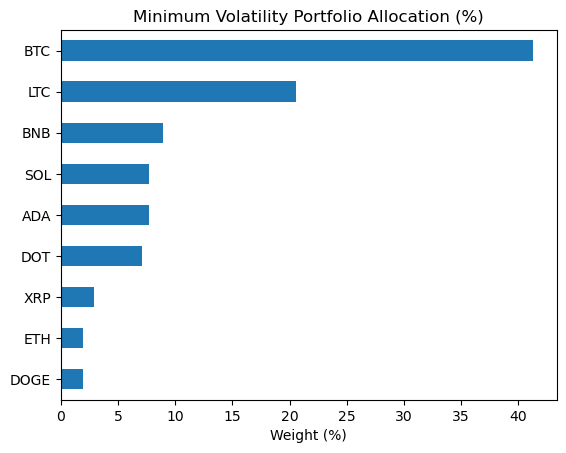

In [16]:
# Min volatility allocation
(min_vol_weights * 100).sort_values().plot(kind="barh", title="Minimum Volatility Portfolio Allocation (%)")
plt.xlabel("Weight (%)")
plt.show()

In [17]:
# Dataset for dashboard
portfolio_df.to_csv("../Data/processed/portfolio_simulations.csv", index=False)
max_sharpe_portfolio.to_frame().T.to_csv("../Data/processed/max_sharpe_portfolio.csv", index=False)
min_vol_portfolio.to_frame().T.to_csv("../Data/processed/min_volatility_portfolio.csv", index=False)

# Interpretation 
## Max Sharpe portfolio insight
The maximum Sharpe portfolio represents the allocation that achieved the best historical risk-adjusted return among the simulated portfolios. This means it offered the highest return relative to the level of volatility taken.

## Minimum volatility portfolio insight
The minimum volatility portfolio represents the allocation that minimised overall portfolio risk. While it may not deliver the highest return, it provides a more conservative alternative for investors prioritising stability.

## Diversification insight
Comparing the optimal portfolios helps illustrate how diversification can improve portfolio behaviour relative to holding a single cryptocurrency, such as Bitcoin.